# AI Engineer 1 - Einführung Neuronale Netze

### Aufgabe 1: Konzeptionierung eines Neuronalen Netzes

*Gehen Sie auf den [Tensorflow Playground](https://playground.tensorflow.org). Klicken Sie sich ein Neuronales Netz zusammen, um die gegebenen Probleme zu lösen. Stellen Sie dabei verschiedene Hyperparameter ein (Anzahl Layer, Anzahl Neuronen, Learning Rate, Aktivierungsfunktion, Features). Beobachten Sie die Wirkung verschiedener Einstellung auf die Lernfähigkeit des Modells. Stellen Sie auch das Rauschen (Noise) der Problemstellung höher.*


### Aufgabe: Implementierung eines Perzeptrons
*Nutzen Sie den bereitgestellten (binären) Iris Datensatz und entwickeln Sie ein eigenes Perzeptron from Scratch.*


### Importieren der Bibliotheken

In [1]:
import os
from typing import Tuple

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [2]:
data = pd.read_csv(os.path.join("..", "..", "..", "data", "iris_binary.csv"))

### Preprocessing der Daten

In [3]:
# Wähle 2 Dimensionen
x = data.iloc[:, :2].to_numpy()

# Biarisieren der Zielvariable
y = np.where(data["class"]>=1,1,0)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=45)

### Perceptronarchitektur

In [4]:
# Erstelle ein Perceptronklasse
class Perceptron:
    def __init__(self,x_dim, learning_rate=0.001):
        """Initialiseren der Hyperparameter."""
        self.w = np.random.uniform(-1, 1, size=(x_dim))
        self.lr = learning_rate

        self.error = []
        self.ws = []
        self.bs = []
        self.b = np.random.uniform(-1, 1, size=1)

    def loss(self,y, pred):
        """Verlustfunktion zur Evaluation der Model Performance."""
        # Lege den Wertebereich fest um auch ein mögliches Ergebnis für log(0) zu bekommen
        pred = np.clip(pred, 0.0001, 0.9999)
        loss = - np.mean(y * (np.log(pred)) + (1 - y) * np.log(1 - pred))
        return loss

    def accuracy(self,y, pred):
        """Berechne die Accuracy für die Vorhersagen und die wahren Werte."""
        # Matche die korrekten Vorhersagen
        correct_pred = np.where(y==pred, 1, 0)

        # Berechne das Verhältnis der richtig klassifizierten Vorhersagen
        return np.mean(correct_pred)

    def predict(self,x):
        """
        Berechne das Skalarprodukt zwischen den Inputwerten x und den Gewichten w. Addiere den Bias.
        Wenn das Ergebnis größer als 0 ist, wird Klasse 1 zurückgegeben, sonst 0.
        """
        return np.where(np.dot(x, self.w) + self.b >= 0, 1, 0)

    def iterations(self, x, y , n_iterations):
        """
        Für jede Iteration berechene die Vorhersage und den Fehler jeder Instanz, update die
        Gewichte und den Bias nach der Updateregel.
        Speicher alle Gewichte, Biases und die Fehler um sie später visualisieren zu können.
        """
        for _ in range(n_iterations):
            # initalisiere Fehlerliste für die Iteration
            errors = []

            # Für jedes Paar von Instanz und Klasse
            for xi, yi in zip(x, y):
                # Klasse vorhersagen mit dem Model
                pred = self.predict(xi)

                # Berechne und Speicher den Loss (Unterschied zwischen echtem und hervorgesagtem y)
                errors.append(self.loss(yi, pred))

                # Anpassen der Gewichte und des Bias basierend auf der Updateregel
                self.w = self.w + self.lr * (yi - pred) * xi
                self.b = self.b + self.lr * (yi - pred)

            # Speichern des mittleren Fehlers, Gewichte und Bias zur späteren Visualisierung
            self.error.append(np.mean(errors))
            self.ws.append(self.w)
            self.bs.append(self.b)

### Trainieren des Modells

In [5]:
# Initialisiere das Model.
model = Perceptron(x_dim=x_train.shape[1])

# Trainiere das Modell mit den Trainingsdaten
model.iterations(x_train, y_train, n_iterations=100)

### Evaluieren des Modells

In [6]:
def evaluation_measures(
    y_test: np.ndarray, y_pred: np.ndarray
) -> Tuple[str, Tuple[int, int, int], np.ndarray]:
    """Evaluiere die Vorhersagen anhand der wahren Ergebnisse.

    Args:
        y_test (np.ndarray): Wahre Ergebnisse.
        y_pred (np.ndarray): Vorhersagen des Modells.

    Returns:
        Tuple[str, Tuple[int, int, int], np.ndarray]: Klassifikationsreport, Tupel aus
            false-positive Rate, true positive Rate und dem AUC Wert der ROC Kurve und  die
            Confusionmatrix.
    """
    # Klassifikationsreport erstellen
    cr = metrics.classification_report(y_test, y_pred)

    # Die false poitive und true positiv rate wird für die ROC Kurve berechnet
    fpr, tpr, threshold = metrics.roc_curve(y_test, y_pred)

    # Berechne die Area under the curve (AUC) der ROC Kurve
    roc_auc = metrics.auc(fpr, tpr)

    # Confusionmatrix zeigt an wie viele Instanzen für welche Klassen richtig/falsch
    # klassifiziert wurden
    cm = metrics.confusion_matrix(y_test, y_pred)

    return cr, (fpr, tpr, roc_auc), cm

def plot_roc(auc_tuple: Tuple[int, int, int]) -> None:
    """Darstellung er ROC Kurve.

    Args:
        auc_tuple (Tuple[int, int, int]): Tupel aus false-positive Rate, true positive Rate und dem
            AUC Wert der ROC Kurve
    """
    # Entpacken des Tupels
    fpr, tpr, roc_auc = auc_tuple
    fig, ax = plt.subplots(figsize=(10, 5))
    plt.title('Receiver Operating Characteristic')

    # plot der Kurve und Hinzufügen eines Labels mit dem AUC Wert
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.show()

def plot_cm(cm: np.ndarray) -> None:
    """Darstellung der Confusionmatrix.

    Args:
        cm (np.ndarray): Berechnete Werte für true negative, false positive, false negative und
            true positive.
    """
    disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Reds")
    plt.show()


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        34

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



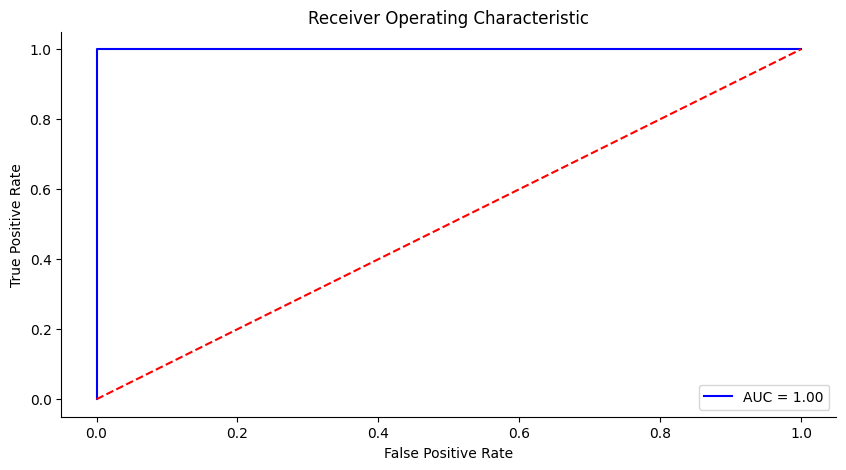

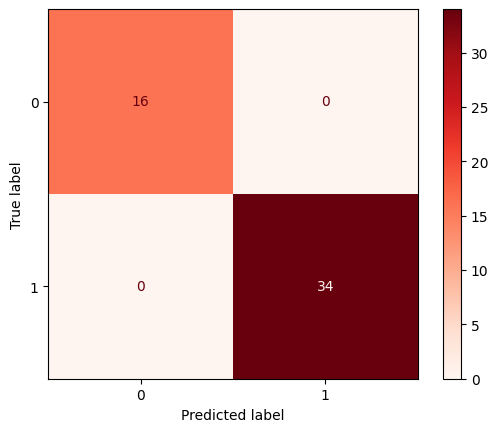

In [7]:
# Klassifiziere das Testset mit dem trainierten Modell
y_pred = model.predict(x_test)
y_true = np.copy(y_test)

# Berechne die Accuracy für das Testset
model.accuracy(y_test, y_pred)

# Evaluiere das Modell basierend auf dem Testset
cr, roc, cm = evaluation_measures(y_test, y_pred)
print(cr)
plot_roc(roc)
plot_cm(cm)


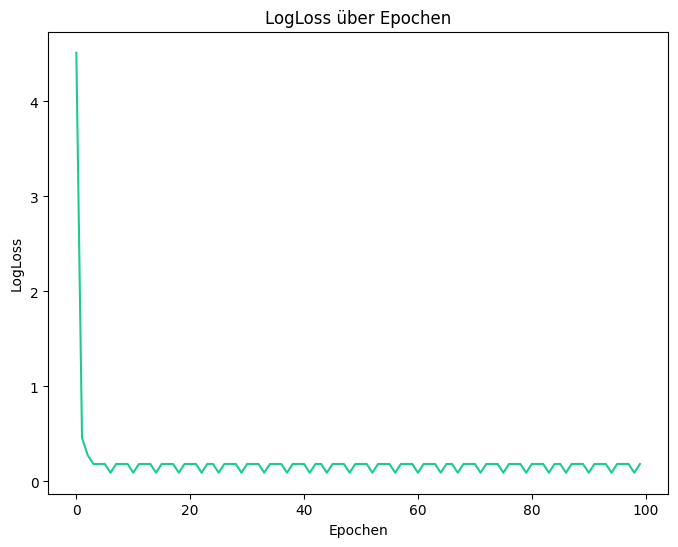

In [8]:
# Darstellung der Verlustfunktion über mehrere Iterationen
plt.figure(figsize=(8,6))
plt.plot(model.error,c="#1ACC94")
plt.title("LogLoss über Epochen")
plt.xlabel("Epochen")
plt.ylabel("LogLoss")
plt.show()

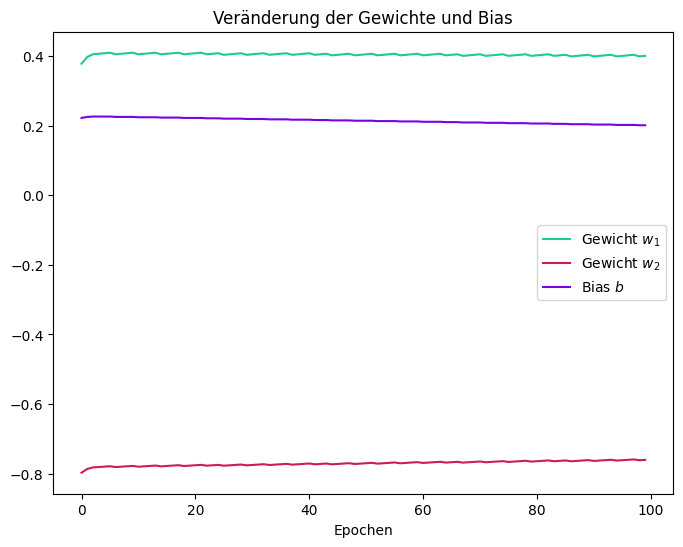

In [9]:
# Darstellung der Gewichte und des Bias über die Iterationen
colors = ["#1ACC94","#CC1B58","#7902E5"]
plt.figure(figsize=(8,6))
for i, w in enumerate(np.array(model.ws).T):
    plt.plot(w,label="Gewicht $w_{}$".format(i+1),c=colors[i])
plt.plot(model.bs,label="Bias $b$",c=colors[-1])
plt.title("Veränderung der Gewichte und Bias")
plt.xlabel("Epochen")
plt.legend()
plt.show()


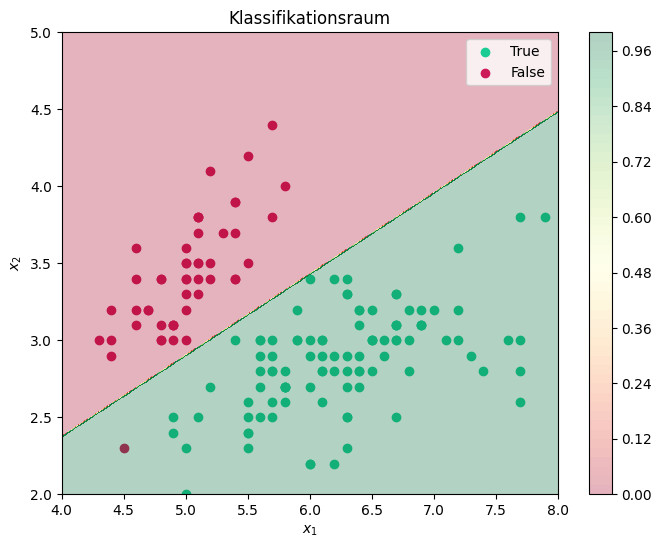

In [10]:
from matplotlib import cm
# Darstellung des Klassifikationsraums
n = 500
z = []
meshgrid = np.meshgrid(np.linspace(4,8,n),np.linspace(2,5,n))
for value in np.nditer(meshgrid):
    z.append(model.predict(np.array(value)).item())

plt.figure(figsize=(8,6))

# Darstellung aller X-Werte und ihrer Klassen
plt.scatter(x[np.where(y==1),:1],x[np.where(y==1),1:2],c="#1ACC94",label="True")
plt.scatter(x[np.where(y==0),:1],x[np.where(y==0),1:2],c="#CC1B58",label="False")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

# Darstellung der Ergebnise anhand einer Contourmap mit Einfärbung der Wahrscheinlichkeiten
contourf_ = plt.contourf(
    meshgrid[0], meshgrid[1], np.array(z).reshape(n, n), cmap=cm.RdYlGn,levels=50,alpha=0.3)

# Hinzufügen des Balkens für die Farbskala
plt.colorbar(contourf_)
plt.xlim(4,8)
plt.ylim(2,5)
plt.legend()
plt.title("Klassifikationsraum")
plt.show()